In [2]:
import numpy as np
import pandas as pd


In [4]:
df= pd.read_csv('car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [9]:
df['Fuel_Type'] = df['Fuel_Type'].map({
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2
})

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    int64  
 6   Seller_Type    301 non-null    int64  
 7   Transmission   301 non-null    int64  
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 21.3+ KB


In [11]:
df['Seller_Type'] = df['Seller_Type'].map({
    'Dealer': 0,
    'Individual': 1
})


In [13]:
df['Transmission'] = df['Transmission'].map({
    'Manual': 0,
    'Automatic': 1
})


In [15]:
df.drop(columns=['Car_Name'],inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    int64  
 5   Seller_Type    301 non-null    int64  
 6   Transmission   301 non-null    int64  
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 18.9 KB


In [17]:
df['Age']=2025-df['Year']

In [18]:
df=df.drop(columns=['Year'])

In [19]:
X=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (240, 7)
x test:  (61, 7)
y train:  (240,)
y test:  (61,)


In [22]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred=lr.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

print(r2,mse,mae)


0.8484549412090381 3.2876460857158336 1.153004591615891


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import SGDRegressor
sgd_batch = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.001,
    max_iter=3000,
    tol=None,
    shuffle=False,
    random_state=42
)

sgd_batch.fit(X_train_scaled, y_train)
y_pred_batch = sgd_batch.predict(X_test_scaled)

print("Batch-like GD Results")
r2_bgd= r2_score(y_test, y_pred_batch)
print("R2:" , r2_bgd )
print("MAE:", mean_absolute_error(y_test, y_pred_batch))
print("MSE:", mean_squared_error(y_test, y_pred_batch))

Batch-like GD Results
R2: 0.8486672039874729
MAE: 1.1509585402972782
MSE: 3.2830412183698994


In [63]:
sgd = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,        # SGD behavior
    tol=None,
    random_state=42
)

sgd.fit(X_train_scaled, y_train)
y_pred_sgd = sgd.predict(X_test_scaled)

print("SGD Results")
r2_sgd= r2_score(y_test, y_pred_sgd)
print("R2 :", r2_sgd)
print("MAE:", mean_absolute_error(y_test, y_pred_sgd))
print("MSE:", mean_squared_error(y_test, y_pred_sgd))
print("-"*40)

SGD Results
R2 : 0.8296907467989132
MAE: 1.270224361438298
MSE: 3.6947199342215256
----------------------------------------


In [64]:


sgd_minibatch = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sgd_minibatch.fit(X_train_scaled, y_train)
y_pred_mini = sgd_minibatch.predict(X_test_scaled)

print("Mini-Batch GD Results")
r2_mbgd= r2_score(y_test, y_pred_mini)
print("R2 :", r2_mbgd)
print("MAE:", mean_absolute_error(y_test, y_pred_mini))
print("MSE:", mean_squared_error(y_test, y_pred_mini))
print("-"*40)


Mini-Batch GD Results
R2 : 0.8580956606750241
MAE: 1.1958482867014986
MSE: 3.0784985630667916
----------------------------------------


In [53]:
results = {
    "SGD": y_pred_sgd,
    "MiniBatch": y_pred_mini,
    "BatchLike": y_pred_batch
}

for name, preds in results.items():
    print(f"{name} → R2: {r2_score(y_test, preds):.3f}, "
          f"MAE: {mean_absolute_error(y_test, preds):.3f}, "
          f"MSE: {mean_squared_error(y_test, preds):.3f}")


SGD → R2: 0.830, MAE: 1.270, MSE: 3.695
MiniBatch → R2: 0.858, MAE: 1.196, MSE: 3.078
BatchLike → R2: 0.849, MAE: 1.151, MSE: 3.283


In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("RIDGE RESULTS")
r2_ridge= r2_score(y_test, y_pred_ridge)
print("R2 :", r2_ridge)
print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("MSE :", mean_squared_error(y_test, y_pred_ridge))
print("-"*40)

RIDGE RESULTS
R2  : 0.8489343690689874
MAE : 1.1526328351182846
MSE : 3.2772452904690574
----------------------------------------


In [66]:
lasso = Lasso(alpha=0.01, max_iter=5000)

lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("LASSO RESULTS")
r2_lasso=r2_score(y_test, y_pred_lasso)
print("R2 :", r2_lasso)
print("MAE :", mean_absolute_error(y_test, y_pred_lasso))
print("MSE :", mean_squared_error(y_test, y_pred_lasso))

LASSO RESULTS
R2 : 0.851214393202331
MAE : 1.1438202758056835
MSE : 3.227782031969387


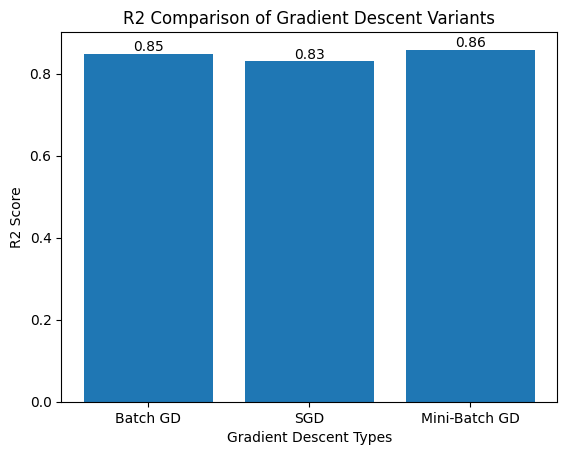

In [67]:
import matplotlib.pyplot as plt

gd_models = ["Batch GD", "SGD", "Mini-Batch GD"]
gd_r2 = [r2_bgd, r2_sgd, r2_mbgd]

plt.figure()
bars = plt.bar(gd_models, gd_r2)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Gradient Descent Types")
plt.ylabel("R2 Score")
plt.title("R2 Comparison of Gradient Descent Variants")
plt.show()

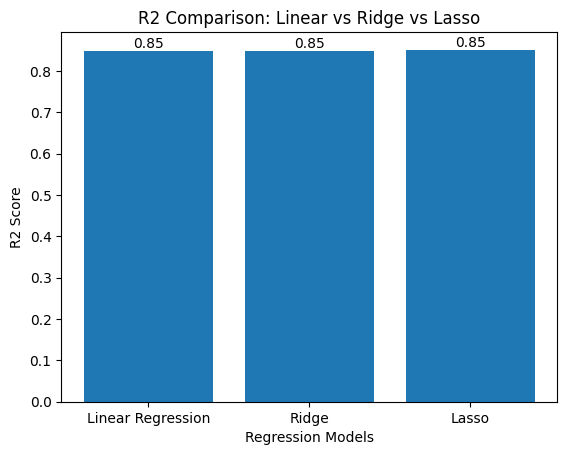

In [68]:
reg_models = ["Linear Regression", "Ridge", "Lasso"]
reg_r2 = [r2_lr, r2_ridge, r2_lasso]

plt.figure()
bars = plt.bar(reg_models, reg_r2)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Regression Models")
plt.ylabel("R2 Score")
plt.title("R2 Comparison: Linear vs Ridge vs Lasso")
plt.show()

In [69]:
import joblib
model = ridge   # or linear_reg / lasso

joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [70]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,0,0,0,0,11
1,4.75,9.54,43000,1,0,0,0,12
2,7.25,9.85,6900,0,0,0,0,8
3,2.85,4.15,5200,0,0,0,0,14
4,4.60,6.87,42450,1,0,0,0,11
